**Objective: Image Path Construction, Multimodal Cohort Indexing, and Retrieval-Ready Image Audit**

The objective of this notebook is to connect the text-integrated clinical cohort from Notebook 02 with its corresponding MIMIC-CXR-JPG image files, generate deterministic image paths, validate image availability, and construct an audit-ready multimodal image index for downstream Explainable Medical LLM development.

This notebook does not perform diagnostic image modeling directly. Instead, it prepares the image-side foundation required for later multimodal learning, retrieval-augmented generation, image-text alignment, captioning, embedding extraction, and leakage-safe evaluation.

**Pipeline Scope**  
◽ Load the text-integrated cohort produced in Notebook 02  
◽ Validate required image-linkage identifiers, including `subject_id`, `study_id`, and `dicom_id`  
◽ Generate deterministic MIMIC-CXR-JPG image paths from canonical identifier structure  
◽ Check image availability using configurable filesystem validation  
◽ Export the multimodal master cohort with image-path metadata  
◽ Produce quality-control reports for missing IDs, unavailable images, CXR shard coverage, and image-linkage multiplicity  
◽ Select one deterministic primary image per clinical episode for simplified downstream workflows  
◽ Define optional audit-first contracts for CLIP embeddings, subject-level splitting, MedTVT modality readiness, PointDetectCount geometry readiness, xHAIM retrieval seeding, and MedBLIP caption prompt preparation  

**Technical and Clinical Significance**  
This notebook creates a reproducible bridge between structured clinical records, extracted radiology text, and chest X-ray image files. Deterministic path generation avoids manual file matching, while audit tables make missing images, incomplete identifiers, and unavailable shards explicit. Subject-level split checks and primary-image selection help prepare the cohort for clinically reliable and leakage-safe multimodal experiments.

**Expected Main Outputs**  
The main outputs of this notebook are:

`multimodal_master_cohort.csv`  
A full image-linked cohort containing generated image paths, CXR shard information, and image-availability metadata.

`multimodal_master_cohort_primary_image.csv`  
A deterministic one-image-per-episode version of the cohort for downstream multimodal modeling and retrieval workflows.

`notebook_03_audit.json`  
A consolidated audit file summarizing the generated artifacts and quality-control outputs.

**Preliminary Setup: Library Import and Shared Helper Functions**

This setup prepares the notebook environment before image-path generation begins. Required libraries are imported, plotting settings are configured, hardware availability is checked, and shared helper functions are registered for selecting the correct image or retrieval dataframe in later stages.

In [1]:
# Imported Libraries (categorized)

# ---------------------------------------------------------
# Standard Library
# ---------------------------------------------------------
import sys
import os

# Add project root to sys.path to resolve 'src' imports
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# ---------------------------------------------------------
# Data Handling and Manipulation Libraries
# ---------------------------------------------------------
import re
import json
from pathlib import Path
from datetime import datetime
from datetime import timezone

# ---------------------------------------------------------
# Core Data and Visualization
# ---------------------------------------------------------
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ---------------------------------------------------------
# Project Utilities
# ---------------------------------------------------------
from src.utils.hardware_verification import verify_hardware

# Global Plot Style Configuration
mpl.rcParams.update({
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   12.5,
    "axes.titleweight": "normal",
    "axes.labelsize":   11.5,
    "axes.labelweight": "normal",
    "xtick.labelsize":  11,
    "ytick.labelsize":  11,
    "legend.fontsize":  10,
    "figure.dpi":       100,
})

print("Libraries imported and academic plotting style successfully applied.")

# Global Device Configuration for PyTorch
device = verify_hardware()
print(f"Global Computation Device Set To: {device}")


Libraries imported and academic plotting style successfully applied.
⏳ Initializing hardware verification protocol...

🖥️ OS: Windows 11 | CPU: Intel64 Family 6 Model 151 Stepping 2, GenuineIntel | RAM: 31.7 GB

✅ GPU Accelerator detected successfully.
🎮 Hardware Device: NVIDIA GeForce RTX 3090
💾 Total VRAM Allocated: 24.00 GB
🚀 System is fully optimized and ready for heavy tensor operations.

🔧 PyTorch Version: 2.6.0+cu124
✅ PyTorch CUDA is available.
   Device Name : NVIDIA GeForce RTX 3090
   CUDA Version: 12.4
   cuDNN Version: 90100
   VRAM (PyTorch): 24.00 GB
   Selected Device: cuda
Global Computation Device Set To: cuda


In [2]:
# ==================================================================
# HELPER FUNCTIONS — Image DataFrame & Path Resolver
# ==================================================================

def resolve_image_dataframe(step_label: str = "") -> tuple[pd.DataFrame, str]:
    """
    Resolve the active primary-image DataFrame from memory or disk.

    Priority order:
      1. df_primary_export  (in-memory, preferred)
      2. df_primary         (in-memory, fallback)
      3. OUTPUTS_DIR / multimodal_master_cohort_primary_image.csv  (disk, Step 4 output)
      4. OUTPUTS_DIR / multimodal_master_cohort.csv                (disk, Step 3 output)
      5. BASE_DIR equivalents as final fallback

    Returns
    -------
    img_df      : pd.DataFrame  — resolved dataframe (copy)
    source_name : str           — variable name or file path used
    """
    # Memory-first resolution
    for var_name in ["df_primary_export", "df_primary"]:
        obj = globals().get(var_name)
        if isinstance(obj, pd.DataFrame) and len(obj) > 0:
            return obj.copy(), var_name

    # Disk fallback — Step 4 output must be first
    base = globals().get("BASE_DIR", Path.cwd())
    out  = globals().get("OUTPUTS_DIR", base / "outputs")

    for p in [
        out  / "multimodal_master_cohort_primary_image.csv",   # Step 4 output — first
        base / "multimodal_master_cohort_primary_image.csv",   # fallback if OUTPUTS_DIR differs
        out  / "multimodal_master_cohort.csv",                 # Step 3 output
        base / "multimodal_master_cohort.csv",                 # final fallback
    ]:
        if p.exists():
            try:
                df = pd.read_csv(p)
                if len(df) > 0:
                    return df, str(p)
            except Exception:
                continue

    raise RuntimeError(
        f"[{step_label}] No image-linked dataframe found in memory or on disk. "
        "Run Steps 1–4 first."
    )


def resolve_retrieval_dataframe(step_label: str = "") -> tuple[pd.DataFrame, str]:
    """
    Resolve the active retrieval/embedding DataFrame from memory or disk.
    Used by Steps 9 (xHAIM) and 10 (MedBLIP) which operate on retrieval outputs.

    Priority order:
      1. In-memory: df_primary_export → df_primary → df_retrieval → retrieval_df
      2. OUTPUTS_DIR / clip_image_embeddings_index_03.csv   (CLIP extraction output)
      3. OUTPUTS_DIR / retrieval_df_final.csv
      4. OUTPUTS_DIR / image_retrieval_index_03.csv
    """
    for var_name in ["df_primary_export", "df_primary", "df_retrieval", "retrieval_df"]:
        obj = globals().get(var_name)
        if isinstance(obj, pd.DataFrame) and len(obj) > 0:
            return obj.copy(), var_name

    out = globals().get("OUTPUTS_DIR", globals().get("BASE_DIR", Path.cwd()) / "outputs")

    for p in [
        out / "clip_image_embeddings_index_03.csv",
        out / "retrieval_df_final.csv",
        out / "image_retrieval_index_03.csv",
    ]:
        if p.exists():
            try:
                df = pd.read_csv(p)
                if len(df) > 0:
                    return df, str(p)
            except Exception:
                continue

    raise RuntimeError(
        f"[{step_label}] No retrieval dataframe found in memory or on disk. "
        "Run Steps 1–5 first."
    )


print("✅ Helper functions registered: resolve_image_dataframe(), resolve_retrieval_dataframe()")


✅ Helper functions registered: resolve_image_dataframe(), resolve_retrieval_dataframe()


**Step 1: Environment Initialization and Text-Integrated Cohort Loading**

This step loads the text-integrated cohort created in Notebook 02 and prepares the local image-processing environment. It defines the output folders, sets the MIMIC-CXR-JPG image root, specifies available image shards, and validates the identifiers required for deterministic image-path generation.

**Main Operations**  
◽ Define the local dataset directory and shared output folders  
◽ Load `cohort_text_integrated.csv` from the previous notebook  
◽ Set the MIMIC-CXR-JPG image root and available CXR shard list  
◽ Validate required image-linkage identifiers: `subject_id`, `study_id`, and `dicom_id`  
◽ Standardize identifier formats for path construction  
◽ Remove rows with missing or invalid image identifiers  
◽ Initialize the image-path audit dictionary  

**Technical and Clinical Significance**  
This step ensures that only rows with valid image-linkage identifiers are passed to the image-path construction stage. Since MIMIC-CXR-JPG paths are generated from `subject_id`, `study_id`, and `dicom_id`, incorrect or missing identifiers would break the connection between the clinical record and the chest X-ray file.

**Expected Outcome**  
A validated `df_cohort` dataframe is available for image-path generation, and initial audit statistics are stored in `image_path_audit`.

In [3]:
# Step 1: Environment configuration and ingestion of the text-integrated cohort

print("Initializing base directory for local Windows environment...")

BASE_DIR = Path.home() / "OneDrive - hull.ac.uk" / "Explainable Medical LLM Dataset" / "datasets"
print(f"Base directory: {BASE_DIR}")

# ---------------------------------------------------------
# 0) Global output directories (defined once, used by all downstream steps)
# ---------------------------------------------------------
QUALITY_DIR = BASE_DIR / "quality_reports"
OUTPUTS_DIR = BASE_DIR / "outputs"
QUALITY_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Quality reports : {QUALITY_DIR}")
print(f"Outputs         : {OUTPUTS_DIR}")

# ---------------------------------------------------------
# 1) Input paths and image-shard configuration
# ---------------------------------------------------------
PATH_TEXT_COHORT = BASE_DIR / "cohort_text_integrated.csv"

# Root directory of MIMIC-CXR-JPG image files.
# IMPORTANT:
# This path must point to the "files" directory, not directly to "p10".
# Expected structure:
#   CXR_IMAGE_ROOT / p10 / p10000032 / s50414267 / <dicom_id>.jpg
CXR_IMAGE_ROOT = Path(r"D:/RS/physionet.org/files/mimic-cxr-jpg/2.1.0/files")
PATH_CXR_IMAGES = CXR_IMAGE_ROOT

# Image shards currently available on disk.
# Add more shards here when they are downloaded, e.g. {"p10", "p11", "p12"}.
AVAILABLE_CXR_GROUPS = {"p10"}

# Keep the full text-integrated cohort by default.
# Later image-only steps can filter to rows with existing images.
FILTER_TO_AVAILABLE_IMAGES = False

print(f"Text cohort path : {PATH_TEXT_COHORT}")
print(f"CXR image root   : {PATH_CXR_IMAGES}")
print(f"Available shards : {sorted(AVAILABLE_CXR_GROUPS)}")
print(f"Filter to images : {FILTER_TO_AVAILABLE_IMAGES}")

if not PATH_TEXT_COHORT.exists():
    raise FileNotFoundError(
        f"Missing required file: {PATH_TEXT_COHORT.name}. Run Notebook 2 first."
    )

if not PATH_CXR_IMAGES.exists():
    print(f"Warning: image root does not exist yet: {PATH_CXR_IMAGES}")
else:
    print("Image root detected.")

if PATH_CXR_IMAGES.name.lower().startswith("p") and PATH_CXR_IMAGES.name[1:].isdigit():
    print(
        "Warning: PATH_CXR_IMAGES appears to point directly to a shard folder. "
        "It should normally point to the parent 'files' directory."
    )

print("\nLoading text-integrated multimodal cohort...")
df_cohort = pd.read_csv(PATH_TEXT_COHORT)
print(f"Loaded rows: {len(df_cohort):,}")

required_id_cols = ["subject_id", "study_id", "dicom_id"]
missing_cols = [c for c in required_id_cols if c not in df_cohort.columns]
if missing_cols:
    raise KeyError(f"Missing required identifier columns: {missing_cols}")

# ---------------------------------------------------------
# 2) Canonical ID normalization for deterministic path generation
# ---------------------------------------------------------
df_cohort["subject_id"] = pd.to_numeric(df_cohort["subject_id"], errors="coerce")
df_cohort["study_id"] = pd.to_numeric(df_cohort["study_id"], errors="coerce")
df_cohort["dicom_id"] = df_cohort["dicom_id"].astype("string").str.strip()

invalid_id_mask = (
    df_cohort["subject_id"].isna()
    | df_cohort["study_id"].isna()
    | df_cohort["dicom_id"].isna()
    | (df_cohort["dicom_id"] == "")
)

audit_cols = [c for c in ["subject_id", "stay_id", "study_id", "dicom_id"] if c in df_cohort.columns]
df_missing_image_ids = df_cohort.loc[invalid_id_mask, audit_cols].copy()

rows_before_id_filter = int(len(df_cohort))
rows_missing_ids = int(invalid_id_mask.sum())

df_cohort = df_cohort.loc[~invalid_id_mask].copy()
df_cohort["subject_id"] = df_cohort["subject_id"].astype(int)
df_cohort["study_id"] = df_cohort["study_id"].astype(int)

print(f"Rows after ID validation     : {len(df_cohort):,}")
print(f"Rows removed (invalid IDs)   : {rows_missing_ids:,}")

image_path_audit = {
    "rows_loaded": rows_before_id_filter,
    "rows_removed_invalid_ids": rows_missing_ids,
    "rows_after_id_validation": int(len(df_cohort)),
    "image_root": str(PATH_CXR_IMAGES),
    "available_cxr_groups": sorted(AVAILABLE_CXR_GROUPS),
    "filter_to_available_images": bool(FILTER_TO_AVAILABLE_IMAGES),
}

Initializing base directory for local Windows environment...
Base directory: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets
Quality reports : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports
Outputs         : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs
Text cohort path : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\cohort_text_integrated.csv
CXR image root   : D:\RS\physionet.org\files\mimic-cxr-jpg\2.1.0\files
Available shards : ['p10']
Filter to images : False
Image root detected.

Loading text-integrated multimodal cohort...
Loaded rows: 88,570
Rows after ID validation     : 88,570
Rows removed (invalid IDs)   : 0


**Step 2: Deterministic Image Path Generation and Availability Check**

This step generates the expected MIMIC-CXR-JPG file path for each validated cohort row. The path is built from the canonical folder structure using `subject_id`, `study_id`, and `dicom_id`, then checked against the configured image shards when filesystem validation is enabled.
<div style="width:60%">

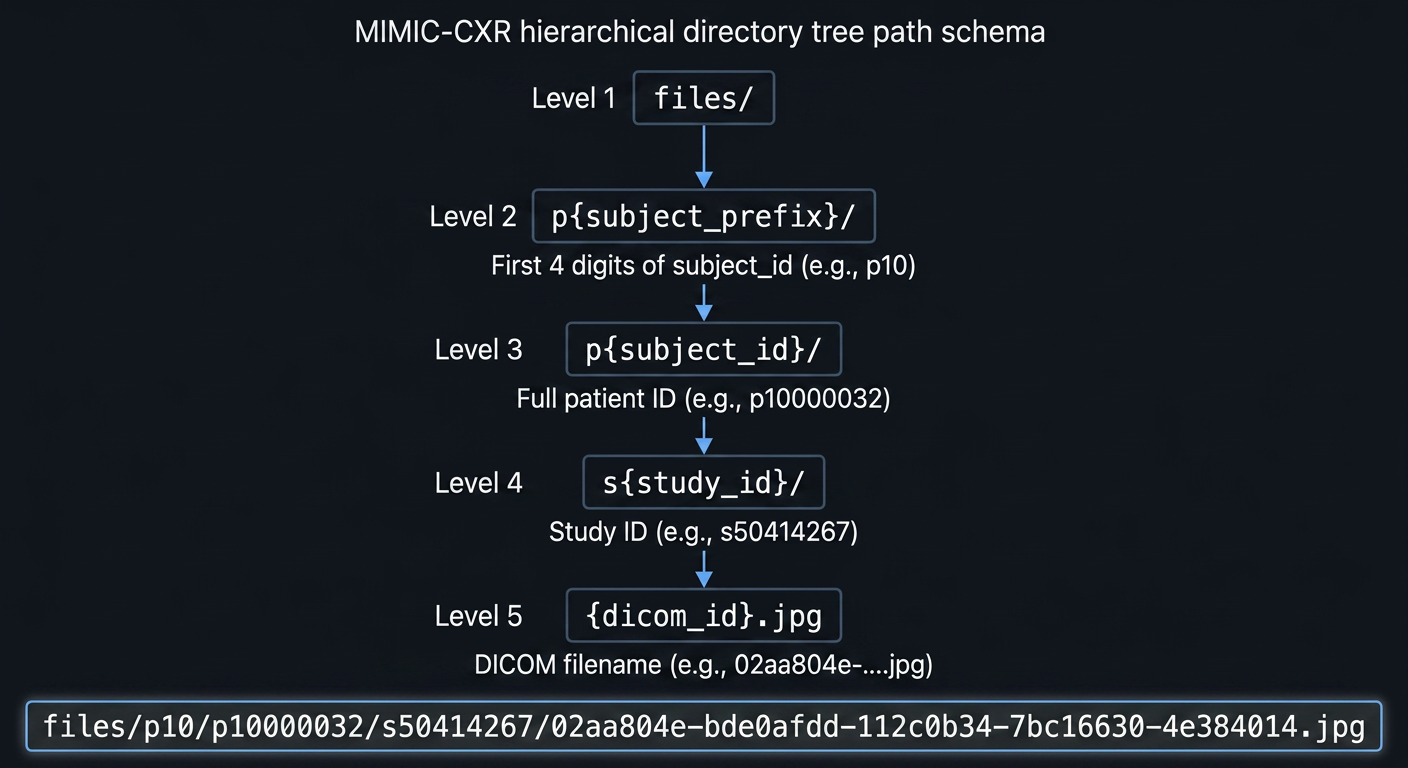
</div>

**Main Operations**  
◽ Derive the CXR shard group from each `subject_id`  
◽ Construct the expected image path for every validated image row  
◽ Store the generated path in both `expected_image_path` and `image_path`  
◽ Mark whether each row belongs to an available CXR shard  
◽ Run configurable image-existence checking using `none`, `sample`, or `full` mode  
◽ Create an optional confirmed-image subset for image-only workflows  
◽ Update audit statistics for generated paths, checked rows, and available images  

**Technical and Clinical Significance**  
Deterministic path generation avoids manual image matching and keeps the pipeline reproducible. The availability check separates rows with generated paths from rows whose image files are actually accessible on disk, which is important before CLIP embedding, captioning, retrieval indexing, or any image-based modeling.

**Expected Outcome**  
The cohort receives image-path metadata, CXR shard availability flags, image-existence status when checked, and updated audit statistics for image linkage quality.




In [4]:
# Step 2: Procedural generation of exact image file paths and configurable existence checking

print("Initiating deterministic image path generation...")

if "df_cohort" not in globals():
    raise RuntimeError("df_cohort not found. Run Step 1 first.")

if "PATH_CXR_IMAGES" not in globals():
    raise RuntimeError("PATH_CXR_IMAGES not found. Run Step 1 first.")

if "AVAILABLE_CXR_GROUPS" not in globals():
    AVAILABLE_CXR_GROUPS = set()

# Image existence check mode:
# - none: do not check filesystem, generate paths only.
# - sample: check a deterministic subset from available CXR groups.
# - full: check all rows from available CXR groups.
IMAGE_CHECK_MODE = "full"
IMAGE_CHECK_SAMPLE_SIZE = 5000
IMAGE_CHECK_RANDOM_SEED = 42

valid_modes = {"none", "sample", "full"}
if IMAGE_CHECK_MODE not in valid_modes:
    raise ValueError(f"IMAGE_CHECK_MODE must be one of {sorted(valid_modes)}")


def get_cxr_group(subject_id) -> str:
    subject_id_str = str(int(subject_id))
    return f"p{subject_id_str[:2]}"


def construct_image_path(row, base_image_dir):
    subject_id_str = str(int(row["subject_id"]))
    study_id_str = str(int(row["study_id"]))
    dicom_id_str = str(row["dicom_id"]).strip()

    folder_group = f"p{subject_id_str[:2]}"
    patient_folder = f"p{subject_id_str}"
    study_folder = f"s{study_id_str}"
    filename = f"{dicom_id_str}.jpg"

    return str(base_image_dir / folder_group / patient_folder / study_folder / filename)


# 1) Generate expected paths and shard labels for all validated rows.
df_cohort["cxr_group"] = df_cohort["subject_id"].apply(get_cxr_group)

available_groups = {str(g).strip() for g in AVAILABLE_CXR_GROUPS if str(g).strip()}
if available_groups:
    df_cohort["cxr_group_available"] = df_cohort["cxr_group"].isin(available_groups)
else:
    df_cohort["cxr_group_available"] = True
    print("Warning: AVAILABLE_CXR_GROUPS is empty. All CXR groups will be treated as available.")

df_cohort["expected_image_path"] = df_cohort.apply(
    lambda row: construct_image_path(row, PATH_CXR_IMAGES),
    axis=1,
)

# Standard downstream alias. Later steps should prefer image_path.
df_cohort["image_path"] = df_cohort["expected_image_path"]

# 2) Configurable filesystem existence check.
total_rows = int(len(df_cohort))
rows_in_available_groups = int(df_cohort["cxr_group_available"].sum())
rows_outside_available_groups = total_rows - rows_in_available_groups

df_cohort["image_exists"] = pd.Series([pd.NA] * total_rows, index=df_cohort.index, dtype="boolean")

eligible_check_index = df_cohort.index[df_cohort["cxr_group_available"]].tolist()

if IMAGE_CHECK_MODE == "none":
    checked_rows = 0
    present_rows = 0
    print("Image existence check skipped (mode='none').")

elif IMAGE_CHECK_MODE == "full":
    print(f"Running full image existence check on available CXR groups: {sorted(available_groups)}")
    print(f"Rows eligible for checking: {len(eligible_check_index):,}")

    checked_exists = df_cohort.loc[eligible_check_index, "expected_image_path"].apply(lambda p: Path(p).exists())
    df_cohort.loc[eligible_check_index, "image_exists"] = checked_exists.astype("boolean")

    checked_rows = int(len(eligible_check_index))
    present_rows = int(checked_exists.sum())

else:
    sample_n = min(IMAGE_CHECK_SAMPLE_SIZE, len(eligible_check_index))
    print(f"Running sampled image existence check on {sample_n:,} rows from available CXR groups.")
    print(f"Available CXR groups: {sorted(available_groups)}")

    if sample_n > 0:
        sampled_index = (
            df_cohort.loc[eligible_check_index]
            .sample(n=sample_n, random_state=IMAGE_CHECK_RANDOM_SEED)
            .index
        )
        sampled_exists = df_cohort.loc[sampled_index, "expected_image_path"].apply(lambda p: Path(p).exists())
        df_cohort.loc[sampled_index, "image_exists"] = sampled_exists.astype("boolean")

        checked_rows = int(sample_n)
        present_rows = int(sampled_exists.sum())
    else:
        checked_rows = 0
        present_rows = 0

checked_rate_total = (checked_rows / max(total_rows, 1)) * 100.0
checked_rate_available = (checked_rows / max(rows_in_available_groups, 1)) * 100.0
present_rate_checked = (present_rows / max(checked_rows, 1)) * 100.0 if checked_rows > 0 else 0.0

confirmed_existing_rows = int(df_cohort["image_exists"].fillna(False).sum())

print("Path generation completed.")
print(f"Rows with generated paths              : {total_rows:,}")
print(f"Rows in available CXR groups           : {rows_in_available_groups:,}")
print(f"Rows outside available CXR groups      : {rows_outside_available_groups:,}")
print(f"Image-check mode                       : {IMAGE_CHECK_MODE}")
print(f"Rows checked for existence             : {checked_rows:,} ({checked_rate_total:.2f}% of total)")
print(f"Rows checked within available groups   : {checked_rate_available:.2f}%")
if checked_rows > 0:
    print(f"Rows present on disk among checked rows: {present_rows:,} ({present_rate_checked:.2f}%)")
else:
    print("Rows present on disk among checked rows: not evaluated")

# Optional confirmed-image subset for image-only downstream experiments.
# The main df_cohort is preserved unless FILTER_TO_AVAILABLE_IMAGES is explicitly True.
df_cohort_image_available = df_cohort.loc[df_cohort["image_exists"].fillna(False)].copy()

if globals().get("FILTER_TO_AVAILABLE_IMAGES", False):
    print(
        "FILTER_TO_AVAILABLE_IMAGES=True: df_cohort will be restricted to confirmed existing images. "
        "Use IMAGE_CHECK_MODE='full' for complete filtering."
    )
    df_cohort = df_cohort_image_available.copy()
    print(f"Rows retained after confirmed-image filtering: {len(df_cohort):,}")

preview_cols = [
    c for c in [
        "subject_id",
        "study_id",
        "dicom_id",
        "cxr_group",
        "cxr_group_available",
        "image_path",
        "image_exists",
    ]
    if c in df_cohort.columns
]
display(df_cohort[preview_cols].head())

image_path_audit.update({
    "rows_with_generated_paths": total_rows,
    "available_cxr_groups": sorted(available_groups),
    "rows_in_available_cxr_groups": rows_in_available_groups,
    "rows_outside_available_cxr_groups": rows_outside_available_groups,
    "image_check_mode": IMAGE_CHECK_MODE,
    "image_check_sample_size": int(IMAGE_CHECK_SAMPLE_SIZE),
    "image_check_random_seed": int(IMAGE_CHECK_RANDOM_SEED),
    "rows_checked_for_existence": checked_rows,
    "rows_present_on_disk_checked": present_rows,
    "rows_confirmed_existing_images": confirmed_existing_rows,
    "rows_checked_rate_total_pct": round(checked_rate_total, 4),
    "rows_checked_rate_available_groups_pct": round(checked_rate_available, 4),
    "rows_present_rate_among_checked_pct": round(present_rate_checked, 4) if checked_rows > 0 else None,
})


Initiating deterministic image path generation...
Running full image existence check on available CXR groups: ['p10']
Rows eligible for checking: 8,440
Path generation completed.
Rows with generated paths              : 88,570
Rows in available CXR groups           : 8,440
Rows outside available CXR groups      : 80,130
Image-check mode                       : full
Rows checked for existence             : 8,440 (9.53% of total)
Rows checked within available groups   : 100.00%
Rows present on disk among checked rows: 8,440 (100.00%)


,subject_id,study_id,dicom_id,cxr_group,cxr_group_available,image_path,image_exists
0,10000032,53911762,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,p10,True,D:\RS\physionet.org\files\mimic-cxr-jpg\2.1.0\...,True
1,10000032,50414267,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,p10,True,D:\RS\physionet.org\files\mimic-cxr-jpg\2.1.0\...,True
2,10000032,56699142,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c,p10,True,D:\RS\physionet.org\files\mimic-cxr-jpg\2.1.0\...,True
3,10000032,53189527,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,p10,True,D:\RS\physionet.org\files\mimic-cxr-jpg\2.1.0\...,True
4,10000032,53911762,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,p10,True,D:\RS\physionet.org\files\mimic-cxr-jpg\2.1.0\...,True


**Step 3: Master Multimodal Cohort Export and Image-Linkage Diagnostics**

This step exports the complete image-linked cohort and saves deterministic quality-control artifacts. It keeps the full multimodal master table while separately recording rows with invalid identifiers, missing checked images, CXR shard coverage, image-linkage multiplicity, view-position distribution, and datetime parsing quality.

**Main Operations**  
◽ Export the full image-linked cohort as `multimodal_master_cohort.csv`  
◽ Save rows removed because of missing or invalid image identifiers  
◽ Save checked rows whose image files were not found on disk  
◽ Export the image-path generation audit JSON  
◽ Summarize row counts by CXR shard group  
◽ Audit image-linkage multiplicity per clinical stay  
◽ Summarize `ViewPosition` distribution when available  
◽ Check datetime parsing quality for available time columns  

**Technical and Clinical Significance**  
This step creates the main image-linked dataset while preserving transparent quality-control records. The diagnostic files make it possible to inspect missing files, unavailable shards, repeated image links per episode, and metadata consistency before downstream multimodal modeling.

**Expected Outcome**  
The master image-linked cohort and supporting image-linkage quality reports are saved for downstream workflows.

In [5]:
# Step 3: Exporting the complete multimodal master index, path-generation audits,
#          and deterministic image-linkage quality diagnostics

if "df_cohort" not in globals():
    raise RuntimeError("df_cohort not found. Run Steps 1-2 first.")

# ================================= Section A: Export master artifact ==========================================
output_filename = "multimodal_master_cohort.csv"
output_path = OUTPUTS_DIR / output_filename
quality_dir = QUALITY_DIR

print(f"Initiating export of master multimodal cohort to:\n  {output_path}")
df_cohort.to_csv(output_path, index=False)

quality_dir.mkdir(parents=True, exist_ok=True)

audit_json_path = quality_dir / "image_path_generation_audit.json"
missing_ids_path = quality_dir / "image_rows_missing_ids.csv"
missing_on_disk_path = quality_dir / "image_paths_missing_on_disk_checked_rows.csv"

# Export rows removed by identifier guards.
if "df_missing_image_ids" in globals() and len(df_missing_image_ids) > 0:
    df_missing_image_ids.to_csv(missing_ids_path, index=False)
else:
    pd.DataFrame(columns=["subject_id", "stay_id", "study_id", "dicom_id"]).to_csv(
        missing_ids_path, index=False
    )

# Export rows checked on disk and found missing.
if "image_exists" in df_cohort.columns:
    checked_mask = df_cohort["image_exists"].notna()
    missing_cols = [
        c for c in [
            "subject_id",
            "stay_id",
            "study_id",
            "dicom_id",
            "cxr_group",
            "cxr_group_available",
            "expected_image_path",
            "image_path",
        ]
        if c in df_cohort.columns
    ]

    missing_on_disk_df = df_cohort.loc[
        checked_mask & (df_cohort["image_exists"] == False),
        missing_cols,
    ].copy()

    missing_on_disk_df.to_csv(missing_on_disk_path, index=False)
    rows_missing_on_disk_checked = int(len(missing_on_disk_df))
else:
    pd.DataFrame(
        columns=[
            "subject_id",
            "stay_id",
            "study_id",
            "dicom_id",
            "cxr_group",
            "cxr_group_available",
            "expected_image_path",
            "image_path",
        ]
    ).to_csv(missing_on_disk_path, index=False)
    rows_missing_on_disk_checked = 0

# Persist audit payload.
if "image_path_audit" not in globals():
    image_path_audit = {}

file_size_mb = os.path.getsize(output_path) / (1024 * 1024)

if "cxr_group" in df_cohort.columns:
    cxr_group_summary = (
        df_cohort["cxr_group"]
        .fillna("MISSING")
        .astype(str)
        .value_counts()
        .sort_index()
        .to_dict()
    )
else:
    cxr_group_summary = {}

if "cxr_group_available" in df_cohort.columns:
    rows_in_available_groups = int(df_cohort["cxr_group_available"].fillna(False).sum())
else:
    rows_in_available_groups = None

if "image_exists" in df_cohort.columns:
    rows_confirmed_existing_images = int(df_cohort["image_exists"].fillna(False).sum())
    rows_checked_for_existence = int(df_cohort["image_exists"].notna().sum())
else:
    rows_confirmed_existing_images = None
    rows_checked_for_existence = None

image_path_audit.update({
    "output_csv": str(output_path),
    "output_file_size_mb": round(file_size_mb, 4),
    "rows_missing_on_disk_among_checked": rows_missing_on_disk_checked,
    "rows_checked_for_existence_exported": rows_checked_for_existence,
    "rows_confirmed_existing_images_exported": rows_confirmed_existing_images,
    "rows_in_available_cxr_groups_exported": rows_in_available_groups,
    "cxr_group_row_counts": cxr_group_summary,
    "missing_id_rows_csv": str(missing_ids_path),
    "missing_on_disk_checked_rows_csv": str(missing_on_disk_path),
})

with open(audit_json_path, "w", encoding="utf-8") as f:
    json.dump(image_path_audit, f, indent=2)

print("Master dataset exported successfully.")
print(f"  File size       : {file_size_mb:.2f} MB")
print(f"  Audit JSON      : {audit_json_path}")
print(f"  Missing-ID CSV  : {missing_ids_path}")
print(f"  Missing-disk CSV: {missing_on_disk_path}")

# ============================ Section B: Inline quality diagnostic layer =====================================
print("\nRunning deterministic image-linkage quality diagnostics...")

# df_cohort is always available at Step 3 — use it directly, no candidate scan needed.
img_df = df_cohort.copy()
selected_name = "df_cohort"
print(f"Using dataframe: {selected_name} (rows={len(img_df):,})")
available_cols = set(img_df.columns)

# -- CXR shard audit --
if "cxr_group" in available_cols:
    shard_summary = (
        img_df.groupby("cxr_group", dropna=False)
        .agg(
            rows=("cxr_group", "size"),
            rows_available_group=(
                "cxr_group_available",
                lambda s: int(s.fillna(False).sum()) if "cxr_group_available" in img_df.columns else 0,
            ),
            rows_checked=(
                "image_exists",
                lambda s: int(s.notna().sum()) if "image_exists" in img_df.columns else 0,
            ),
            rows_existing=(
                "image_exists",
                lambda s: int(s.fillna(False).sum()) if "image_exists" in img_df.columns else 0,
            ),
        )
        .reset_index()
        .sort_values("cxr_group")
    )
    shard_summary.to_csv(quality_dir / "image_cxr_group_summary.csv", index=False)
    print("  Saved CXR shard summary.")

# -- Multiplicity audit --
if {"subject_id", "stay_id"}.issubset(available_cols):
    stay_key = ["subject_id", "stay_id"]
    if "study_id" in available_cols:
        multiplicity = (
            img_df[stay_key + ["study_id"]]
            .dropna(subset=stay_key)
            .groupby(stay_key, dropna=False)["study_id"]
            .nunique()
            .rename("n_studies")
            .reset_index()
        )
    else:
        multiplicity = (
            img_df[stay_key]
            .dropna(subset=stay_key)
            .value_counts()
            .rename("n_rows")
            .reset_index()
        )

    multiplicity_summary = pd.DataFrame([
        {"metric": "stays",
         "value": int(len(multiplicity))},
        {"metric": "mean_links_per_stay",
         "value": float(multiplicity.iloc[:, -1].mean()) if len(multiplicity) else 0.0},
        {"metric": "median_links_per_stay",
         "value": float(multiplicity.iloc[:, -1].median()) if len(multiplicity) else 0.0},
        {"metric": "p95_links_per_stay",
         "value": float(multiplicity.iloc[:, -1].quantile(0.95)) if len(multiplicity) else 0.0},
        {"metric": "max_links_per_stay",
         "value": float(multiplicity.iloc[:, -1].max()) if len(multiplicity) else 0.0},
    ])

    multiplicity.to_csv(quality_dir / "image_linkage_multiplicity_per_stay.csv", index=False)
    multiplicity_summary.to_csv(quality_dir / "image_linkage_multiplicity_summary.csv", index=False)
    print("  Saved image linkage multiplicity diagnostics.")
else:
    print("  Required columns subject_id/stay_id missing — multiplicity diagnostics skipped.")

# -- ViewPosition audit --
if "ViewPosition" in available_cols:
    vp_summary = (
        img_df["ViewPosition"]
        .fillna("MISSING").astype(str).str.strip().replace("", "MISSING")
        .value_counts()
        .rename_axis("ViewPosition")
        .reset_index(name="count")
    )
    vp_summary["percent"] = (vp_summary["count"] / max(len(img_df), 1) * 100.0).round(3)
    vp_summary.to_csv(quality_dir / "image_viewposition_summary.csv", index=False)
    print("  Saved ViewPosition quality summary.")

# -- Datetime parse audit --
dt_col_candidates = ["intime", "outtime", "StudyDateTime", "study_datetime", "charttime"]
present_dt_cols = [c for c in dt_col_candidates if c in available_cols]
if present_dt_cols:
    dt_parse_audit = []
    for col in present_dt_cols:
        parsed = pd.to_datetime(img_df[col], errors="coerce")
        dt_parse_audit.append({
            "column": col,
            "non_null_rows": int(img_df[col].notna().sum()),
            "parsed_rows": int(parsed.notna().sum()),
            "parse_rate_pct": round(float(parsed.notna().mean() * 100.0), 3),
        })
    pd.DataFrame(dt_parse_audit).to_csv(
        quality_dir / "image_datetime_parse_audit.csv", index=False
    )
    print("  Saved datetime parse audit.")

print(f"  Quality outputs : {quality_dir}")
print("\nPHASE 3 COMPLETE")


Initiating export of master multimodal cohort to:
  C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\multimodal_master_cohort.csv
Master dataset exported successfully.
  File size       : 176.91 MB
  Audit JSON      : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\image_path_generation_audit.json
  Missing-ID CSV  : C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\image_rows_missing_ids.csv
  Missing-disk CSV: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\image_paths_missing_on_disk_checked_rows.csv

Running deterministic image-linkage quality diagnostics...
Using dataframe: df_cohort (rows=88,570)
  Saved CXR shard summary.
  Saved image linkage multiplicity diagnostics.
  Saved ViewPosition quality summary.
  Saved datetime parse audit.
  Quality outputs : C:\Users\927997\OneDrive - hull.ac.uk\Explainable 

**Step 4: Deterministic Primary-Image Selection and Visual Audit**

This step selects one representative chest X-ray image per clinical episode using a deterministic ranking strategy. The selection prioritizes confirmed image availability, available CXR shards, preferred view positions, temporal proximity to ED admission when possible, and stable identifier-based tie-breaking.

**Main Operations**  
◽ Define episode-level grouping keys using available patient and stay or study identifiers  
◽ Prefer confirmed existing images over missing or unchecked images  
◽ Prefer rows from available CXR shards  
◽ Rank common view positions such as PA and AP before less preferred views  
◽ Use temporal proximity to ED `intime` when study time information is available  
◽ Apply stable tie-breakers using `study_id` and `dicom_id`  
◽ Export the primary-image cohort and multiplicity audit tables  
◽ Generate visual summaries comparing image distributions before and after selection  

**Technical and Clinical Significance**  
Many clinical episodes can be linked to more than one image. Selecting a deterministic primary image creates a simpler one-image-per-episode dataset while keeping the full master cohort available. This is useful for downstream experiments that require a single image input per clinical case.

**Expected Outcome**  
A primary-image cohort is created, along with audit tables and plots describing how image multiplicity was reduced.

Running deterministic primary-image selection...
Primary-image selection complete.


,metric,value
0,rows_before,88570.0
1,rows_after_primary_selection,88570.0
2,episodes,88570.0
3,mean_images_per_episode_before,1.0
4,max_images_per_episode_before,1.0
5,primary_rows_in_available_cxr_groups,8440.0
6,primary_rows_confirmed_existing_images,8440.0


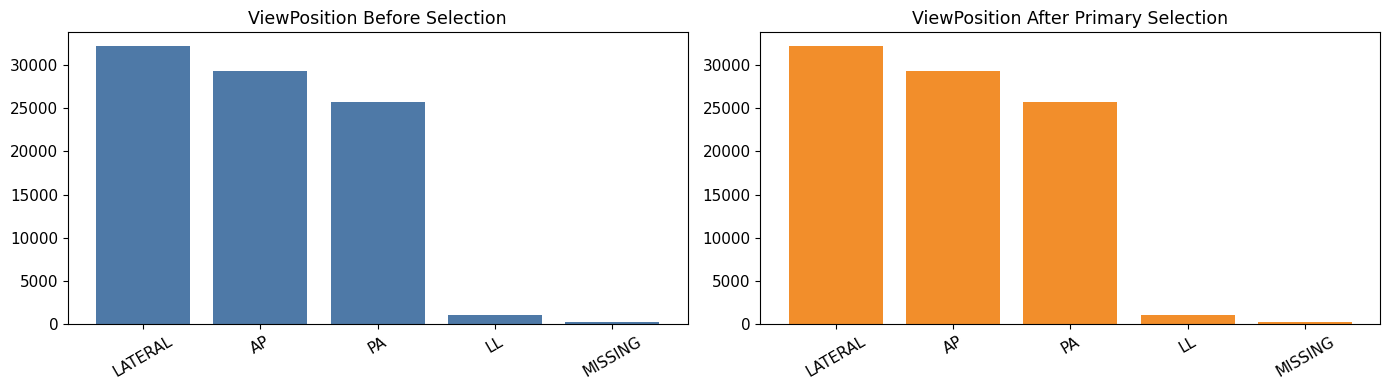

Saved primary dataset: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\multimodal_master_cohort_primary_image.csv
Saved audit: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\primary_image_selection_audit.csv
Saved multiplicity table: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\primary_image_link_multiplicity_before_after.csv
Saved view comparison figure: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\primary_image_selection_view_comparison.png


In [6]:
# Deterministic primary-image selection per episode with audit tables and plots

print("Running deterministic primary-image selection...")

if "df_cohort" not in globals() or not isinstance(df_cohort, pd.DataFrame):
    raise RuntimeError("df_cohort not found. Run Steps 1-3 first.")

df_rank = df_cohort.copy()
available_cols = set(df_rank.columns)

if {"subject_id", "stay_id"}.issubset(available_cols):
    group_keys = ["subject_id", "stay_id"]
elif {"subject_id", "study_id"}.issubset(available_cols):
    group_keys = ["subject_id", "study_id"]
else:
    raise RuntimeError("Could not find grouping keys for deterministic selection.")

# Rank 1: file presence and shard availability.
# Confirmed existing images are preferred, then checked-missing images,
# then unknown/unverified images.
if "image_exists" in df_rank.columns:
    is_present = df_rank["image_exists"].map({True: 0, False: 1}).fillna(2)
else:
    is_present = pd.Series(2, index=df_rank.index)
df_rank["_rank_exists"] = is_present.astype(float)

# Prefer rows from currently available CXR shards when the column exists.
if "cxr_group_available" in df_rank.columns:
    df_rank["_rank_available_group"] = df_rank["cxr_group_available"].map({True: 0, False: 1}).fillna(1).astype(float)
else:
    df_rank["_rank_available_group"] = 1.0

# Rank 2: preferred view ordering.
view_map = {"PA": 0, "AP": 1, "LATERAL": 2, "LL": 3}
if "ViewPosition" in df_rank.columns:
    view_norm = df_rank["ViewPosition"].fillna("MISSING").astype(str).str.strip().str.upper()
    df_rank["_rank_view"] = view_norm.map(view_map).fillna(9).astype(float)
else:
    df_rank["_rank_view"] = 9.0

# Rank 3: temporal proximity to ED intime when possible.
def build_study_datetime(frame: pd.DataFrame) -> pd.Series:
    datetime_candidates = ["study_datetime", "StudyDateTime", "cxr_datetime", "charttime"]
    for c in datetime_candidates:
        if c in frame.columns:
            parsed = pd.to_datetime(frame[c], errors="coerce")
            if parsed.notna().any():
                return parsed

    if {"StudyDate", "StudyTime"}.issubset(set(frame.columns)):
        study_date = frame["StudyDate"].astype("string").str.strip()
        study_time = frame["StudyTime"].astype("string").str.replace(".0", "", regex=False).str.strip()
        study_time = study_time.str.zfill(6)
        merged = study_date + " " + study_time
        return pd.to_datetime(merged, errors="coerce", format="%Y%m%d %H%M%S")

    return pd.Series(pd.NaT, index=frame.index)

study_dt = build_study_datetime(df_rank)
if "intime" in df_rank.columns:
    intime_dt = pd.to_datetime(df_rank["intime"], errors="coerce")
    df_rank["_rank_time_delta_h"] = ((study_dt - intime_dt).abs().dt.total_seconds() / 3600.0).fillna(1e9)
else:
    df_rank["_rank_time_delta_h"] = 1e9

# Stable tie-breakers.
if "study_id" not in df_rank.columns:
    df_rank["study_id"] = -1
if "dicom_id" not in df_rank.columns:
    df_rank["dicom_id"] = ""

df_rank["_rank_dicom"] = df_rank["dicom_id"].astype(str)

df_rank = df_rank.sort_values(
    by=group_keys + [
        "_rank_exists",
        "_rank_available_group",
        "_rank_view",
        "_rank_time_delta_h",
        "study_id",
        "_rank_dicom",
    ],
    ascending=True,
    kind="mergesort",
)

df_primary = df_rank.groupby(group_keys, as_index=False, dropna=False).head(1).copy()

# Multiplicity and audit.
before_mult = df_cohort.groupby(group_keys, dropna=False).size().rename("n_images_before").reset_index()
after_mult = df_primary.groupby(group_keys, dropna=False).size().rename("n_images_after").reset_index()
df_mult = before_mult.merge(after_mult, on=group_keys, how="left")
df_mult["n_images_after"] = df_mult["n_images_after"].fillna(0).astype(int)

summary_rows = [
    {"metric": "rows_before", "value": int(len(df_cohort))},
    {"metric": "rows_after_primary_selection", "value": int(len(df_primary))},
    {"metric": "episodes", "value": int(len(before_mult))},
    {"metric": "mean_images_per_episode_before", "value": round(float(before_mult["n_images_before"].mean()), 4)},
    {"metric": "max_images_per_episode_before", "value": int(before_mult["n_images_before"].max())},
]

if "cxr_group_available" in df_primary.columns:
    summary_rows.append({
        "metric": "primary_rows_in_available_cxr_groups",
        "value": int(df_primary["cxr_group_available"].fillna(False).sum()),
    })

if "image_exists" in df_primary.columns:
    summary_rows.append({
        "metric": "primary_rows_confirmed_existing_images",
        "value": int(df_primary["image_exists"].fillna(False).sum()),
    })

summary = pd.DataFrame(summary_rows)

print("Primary-image selection complete.")
display(summary)

# Visual comparison.
if "ViewPosition" in df_cohort.columns:
    view_before = df_cohort["ViewPosition"].fillna("MISSING").astype(str).str.upper().value_counts().head(10)
    view_after = df_primary["ViewPosition"].fillna("MISSING").astype(str).str.upper().value_counts().head(10)
    view_comp = pd.concat([view_before.rename("before"), view_after.rename("after")], axis=1).fillna(0)
    view_comp = view_comp.sort_values("before", ascending=False).reset_index().rename(columns={"index": "ViewPosition"})

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].bar(view_comp["ViewPosition"], view_comp["before"], color="#4E79A7")
    axes[0].set_title("ViewPosition Before Selection")
    axes[0].tick_params(axis="x", rotation=30)

    axes[1].bar(view_comp["ViewPosition"], view_comp["after"], color="#F28E2B")
    axes[1].set_title("ViewPosition After Primary Selection")
    axes[1].tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.show()
else:
    view_comp = pd.DataFrame(columns=["ViewPosition", "before", "after"])

# Persist outputs.
quality_dir = QUALITY_DIR if "QUALITY_DIR" in globals() else Path.cwd() / "quality_reports"
outputs_dir = OUTPUTS_DIR if "OUTPUTS_DIR" in globals() else Path.cwd() / "outputs"
quality_dir.mkdir(parents=True, exist_ok=True)
outputs_dir.mkdir(parents=True, exist_ok=True)

primary_output = outputs_dir / "multimodal_master_cohort_primary_image.csv"
audit_csv = quality_dir / "primary_image_selection_audit.csv"
mult_csv = quality_dir / "primary_image_link_multiplicity_before_after.csv"
view_plot = quality_dir / "primary_image_selection_view_comparison.png"

# Remove ranking helper columns from final primary dataset.
helper_cols = [c for c in df_primary.columns if c.startswith("_rank_")]
df_primary_export = df_primary.drop(columns=helper_cols)

df_primary_export.to_csv(primary_output, index=False)
summary.to_csv(audit_csv, index=False)
df_mult.to_csv(mult_csv, index=False)

if not view_comp.empty:
    plt.figure(figsize=(10, 4))
    x = np.arange(len(view_comp))
    width = 0.4
    plt.bar(x - width / 2, view_comp["before"], width=width, label="before")
    plt.bar(x + width / 2, view_comp["after"], width=width, label="after")
    plt.xticks(x, view_comp["ViewPosition"], rotation=30)
    plt.title("ViewPosition Distribution: Before vs After")
    plt.legend()
    plt.tight_layout()
    plt.savefig(view_plot, dpi=220, bbox_inches="tight")
    plt.close()

print(f"Saved primary dataset: {primary_output}")
print(f"Saved audit: {audit_csv}")
print(f"Saved multiplicity table: {mult_csv}")
if not view_comp.empty:
    print(f"Saved view comparison figure: {view_plot}")


**Step 5: CLIP Image Embedding Contract and Optional Extraction Layer**

This step prepares the image cohort for CLIP-based embedding workflows. It defines the CLIP preprocessing contract, audits which image rows are eligible for embedding, and optionally supports embedding extraction when the runtime flag is enabled.

**Main Operations**  
◽ Define CLIP runtime settings, including model name, batch size, image limit, and preprocessing specification  
◽ Resolve the best available image-linked dataframe  
◽ Identify the image-path column used for embedding input  
◽ Check missing paths, CXR shard availability, and filesystem existence  
◽ Select eligible image rows for CLIP processing  
◽ Save the CLIP preprocessing contract and input audit table  
◽ Optionally extract image embeddings when `RUN_CLIP_EMBEDDINGS=True`  

**Technical and Clinical Significance**  
This audit-first design separates embedding readiness from model execution. It ensures that only eligible and traceable image rows are passed to CLIP, while preserving a clear record of preprocessing assumptions such as RGB conversion, resizing, cropping, normalization, and file-existence requirements.

**Expected Outcome**  
CLIP-ready input audits and preprocessing contract files are saved. If embedding extraction is enabled, image embedding files and their row-level index are also generated.

In [7]:
# Step 5: OpenAI CLIP embedding integration for CXR images (audit-first, optional extraction)

print("Initializing CLIP integration layer...")

# ---------------------------------------------------------
# 0) Runtime configuration
# ---------------------------------------------------------
RUN_CLIP_EMBEDDINGS = False
CLIP_MODEL_NAME = "ViT-B/32"
CLIP_BATCH_SIZE = 64
CLIP_MAX_IMAGES = 50000
CLIP_REQUIRE_EXISTING_FILES = True
CLIP_RANDOM_SEED = 42

CLIP_PREPROCESS_SPEC = {
    "convert_rgb": True,
    "resize": "shorter_side_to_input_resolution",
    "center_crop": True,
    "normalize_mean": [0.48145466, 0.4578275, 0.40821073],
    "normalize_std": [0.26862954, 0.26130258, 0.27577711],
}

# ---------------------------------------------------------
# 1) Resolve paths and source dataframe
# ---------------------------------------------------------
clip_contract_path = QUALITY_DIR / "clip_preprocess_contract_03.json"
clip_image_audit_path = QUALITY_DIR / "clip_image_embedding_input_audit_03.csv"
clip_run_summary_path = QUALITY_DIR / "clip_embedding_run_summary_03.json"
clip_index_csv_path = OUTPUTS_DIR / "clip_image_embeddings_index_03.csv"
clip_embedding_npy_path = OUTPUTS_DIR / "clip_image_embeddings_03.npy"

source_df, source_name = resolve_image_dataframe(step_label="Step 5: CLIP")
print(f"CLIP source table: {source_name} (rows={len(source_df):,})")

# ---------------------------------------------------------
# 2) Validate required columns
# ---------------------------------------------------------
path_col = next(
    (c for c in ["image_path", "expected_image_path", "cxr_path", "dicom_path"] if c in source_df.columns),
    None,
)
if path_col is None:
    raise KeyError(
        "No image path column found. Expected one of: "
        "image_path, expected_image_path, cxr_path, dicom_path"
    )

id_cols = [c for c in ["subject_id", "stay_id", "hadm_id", "study_id", "dicom_id"] if c in source_df.columns]
if "dicom_id" not in source_df.columns:
    source_df["dicom_id"] = source_df.index.map(lambda i: f"row_{i}")

source_df[path_col] = source_df[path_col].fillna("").astype(str).str.strip()
source_df["path_missing"] = source_df[path_col] == ""

# If shard availability is known, CLIP eligibility should respect it.
if "cxr_group_available" in source_df.columns:
    source_df["clip_cxr_group_available"] = source_df["cxr_group_available"].fillna(False).astype(bool)
else:
    source_df["clip_cxr_group_available"] = True

# Optional disk existence check for robust runtime expectations.
source_df["path_exists"] = source_df[path_col].map(lambda p: Path(p).exists() if p else False)

base_eligible_mask = (~source_df["path_missing"]) & source_df["clip_cxr_group_available"]

if CLIP_REQUIRE_EXISTING_FILES:
    eligible_mask = base_eligible_mask & source_df["path_exists"]
else:
    eligible_mask = base_eligible_mask

eligible_df = source_df.loc[eligible_mask].copy()

# Deterministic sampling for optional extraction.
if len(eligible_df) > CLIP_MAX_IMAGES:
    eligible_df = eligible_df.sample(n=CLIP_MAX_IMAGES, random_state=CLIP_RANDOM_SEED).copy()

eligible_df = eligible_df.reset_index(drop=True)
eligible_df["clip_embedding_row"] = eligible_df.index.astype(int)

# ----------------------------------------------------------
# 3) Persist contract and audit
# ----------------------------------------------------------
contract_payload = {
    "clip_model_name": CLIP_MODEL_NAME,
    "clip_batch_size": int(CLIP_BATCH_SIZE),
    "clip_max_images": int(CLIP_MAX_IMAGES),
    "clip_require_existing_files": bool(CLIP_REQUIRE_EXISTING_FILES),
    "clip_preprocess_spec": CLIP_PREPROCESS_SPEC,
    "source_table": source_name,
    "source_rows": int(len(source_df)),
    "path_column": path_col,
    "eligible_rows": int(len(eligible_df)),
    "respects_cxr_group_available": "cxr_group_available" in source_df.columns,
}

with open(clip_contract_path, "w", encoding="utf-8") as f:
    json.dump(contract_payload, f, indent=2)

audit_rows = pd.DataFrame([
    {"metric": "source_rows", "value": int(len(source_df))},
    {"metric": "path_column", "value": path_col},
    {"metric": "rows_missing_path", "value": int(source_df["path_missing"].sum())},
    {"metric": "rows_in_available_cxr_groups", "value": int(source_df["clip_cxr_group_available"].sum())},
    {"metric": "rows_outside_available_cxr_groups", "value": int((~source_df["clip_cxr_group_available"]).sum())},
    {"metric": "rows_with_existing_path", "value": int(source_df["path_exists"].sum())},
    {"metric": "rows_base_eligible_nonmissing_available_group", "value": int(base_eligible_mask.sum())},
    {"metric": "rows_eligible_for_clip", "value": int(len(eligible_df))},
    {"metric": "clip_require_existing_files", "value": int(CLIP_REQUIRE_EXISTING_FILES)},
    {"metric": "clip_max_images", "value": int(CLIP_MAX_IMAGES)},
])
audit_rows.to_csv(clip_image_audit_path, index=False)

print(f"Saved CLIP contract: {clip_contract_path}")
print(f"Saved CLIP input audit: {clip_image_audit_path}")
print(f"CLIP path column: {path_col}")
print(f"Rows eligible for CLIP: {len(eligible_df):,}")

# ---------------------------------------------------------
# 4) Optional embedding extraction
# ---------------------------------------------------------
if not RUN_CLIP_EMBEDDINGS:
    print("CLIP embedding extraction skipped by default (RUN_CLIP_EMBEDDINGS=False).")
else:
    if len(eligible_df) == 0:
        raise RuntimeError("No eligible images for CLIP embedding extraction.")

    import torch
    from PIL import Image

    try:
        import clip
    except Exception as e:
        raise RuntimeError(
            "Python package 'clip' is not available. Install using: pip install git+https://github.com/openai/CLIP.git"
        ) from e

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model, preprocess = clip.load(CLIP_MODEL_NAME, device=device)
    model.eval()

    all_embeddings = []
    success_rows = []
    failed_rows = []

    total = len(eligible_df)
    n_batches = int(math.ceil(total / CLIP_BATCH_SIZE))

    print(f"Starting CLIP extraction: rows={total:,}, batches={n_batches:,}, device={device}")

    with torch.no_grad():
        for b in range(n_batches):
            st = b * CLIP_BATCH_SIZE
            en = min((b + 1) * CLIP_BATCH_SIZE, total)
            batch = eligible_df.iloc[st:en]

            tensors = []
            row_meta = []

            for _, r in batch.iterrows():
                p = r[path_col]
                try:
                    img = Image.open(p).convert("RGB")
                    t = preprocess(img)
                    tensors.append(t)
                    row_meta.append(r)
                except Exception as ex:
                    failed_rows.append({
                        "path": p,
                        "error": str(ex),
                    })

            if not tensors:
                continue

            image_tensor = torch.stack(tensors).to(device)
            feats = model.encode_image(image_tensor)
            feats = feats / feats.norm(dim=-1, keepdim=True)
            feats_np = feats.detach().cpu().numpy().astype(np.float32)

            all_embeddings.append(feats_np)
            success_rows.extend(row_meta)

    if len(success_rows) == 0:
        raise RuntimeError("CLIP extraction failed for all rows.")

    emb_matrix = np.concatenate(all_embeddings, axis=0)
    np.save(clip_embedding_npy_path, emb_matrix)

    success_df = pd.DataFrame(success_rows)

    keep_cols = [
        c for c in (
            id_cols
            + [
                "cxr_group",
                "cxr_group_available",
                "image_path",
                "expected_image_path",
                path_col,
                "clip_embedding_row",
            ]
        )
        if c in success_df.columns
    ]

    # Preserve column order while avoiding duplicates.
    keep_cols = list(dict.fromkeys(keep_cols))

    success_df = success_df[keep_cols].copy().reset_index(drop=True)
    success_df["clip_embedding_row"] = success_df.index.astype(int)
    success_df.to_csv(clip_index_csv_path, index=False)

    run_summary = {
        "clip_model_name": CLIP_MODEL_NAME,
        "device": device,
        "embedding_dim": int(emb_matrix.shape[1]),
        "rows_encoded": int(emb_matrix.shape[0]),
        "rows_failed": int(len(failed_rows)),
        "path_column": path_col,
        "embedding_file": str(clip_embedding_npy_path),
        "index_file": str(clip_index_csv_path),
    }
    with open(clip_run_summary_path, "w", encoding="utf-8") as f:
        json.dump(run_summary, f, indent=2)

    failed_path = QUALITY_DIR / "clip_embedding_failures_03.csv"
    pd.DataFrame(failed_rows).to_csv(failed_path, index=False)

    print(f"Saved CLIP embeddings: {clip_embedding_npy_path}")
    print(f"Saved CLIP embedding index: {clip_index_csv_path}")
    print(f"Saved CLIP run summary: {clip_run_summary_path}")
    print(f"Saved CLIP failure log: {failed_path}")


Initializing CLIP integration layer...
CLIP source table: df_primary_export (rows=88,570)
Saved CLIP contract: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\clip_preprocess_contract_03.json
Saved CLIP input audit: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\clip_image_embedding_input_audit_03.csv
CLIP path column: image_path
Rows eligible for CLIP: 8,440
CLIP embedding extraction skipped by default (RUN_CLIP_EMBEDDINGS=False).


**Step 6: Subject-Level Split Leakage Guard for Image Cohort**

This step creates a deterministic patient-level split for the image-linked cohort. Subjects are assigned to train, validation, or test sets using a stable MD5 hash, ensuring that the same patient cannot appear across multiple project splits.

**Main Operations**  
◽ Resolve the image-linked cohort source  
◽ Require `subject_id` for patient-level split assignment  
◽ Assign each subject to train, validation, or test using a stable hash rule  
◽ Add both `project_subject_split` and backward-compatible `split` columns  
◽ Check for subject overlap across splits  
◽ Compare project splits with official CXR split columns when available  
◽ Export split maps, leakage audit tables, label distribution summaries, and payload JSON  

**Technical and Clinical Significance**  
Patient-level splitting is essential for preventing leakage in clinical machine learning. If images from the same patient appear in both training and evaluation sets, model performance can become artificially inflated. This step provides a reproducible split strategy and documents leakage risk explicitly.

**Expected Outcome**  
A deterministic subject-level split map and supporting leakage-audit files are saved for later modeling and evaluation notebooks.

In [8]:
# Step 6: CPLLM-inspired subject-level split audit for image-linked cohort

print("Starting Step 6: CPLLM-inspired image split guard...")

import hashlib

img_df, source_name = resolve_image_dataframe(step_label="Step 6: CPLLM Split Guard")
print(f"Source: {source_name} | rows={len(img_df):,}")

id_col = "subject_id" if "subject_id" in img_df.columns else None
if id_col is None:
    raise RuntimeError("subject_id is required for CPLLM-style split-by-patient guard.")

img_df[id_col] = img_df[id_col].astype(str)
subjects = sorted(img_df[id_col].dropna().unique().tolist())

# Deterministic and cross-session stable split assignment by subject key.
# Python's built-in hash() is intentionally randomized between sessions,
# so hashlib is required for reproducible experiments.
def stable_subject_bucket(subject_id: str, salt: str = "cpllm03") -> int:
    key = f"{salt}::{subject_id}".encode("utf-8")
    digest = hashlib.md5(key).hexdigest()
    return int(digest, 16) % 10


def _split(s: str) -> str:
    mod = stable_subject_bucket(s)
    if mod <= 7:
        return "train"
    if mod == 8:
        return "validation"
    return "test"


split_map = pd.DataFrame({id_col: subjects})
split_map["project_subject_split"] = split_map[id_col].map(_split)

# Backward-compatible alias for downstream notebooks that expect "split".
split_map["split"] = split_map["project_subject_split"]

img_df = img_df.merge(split_map, on=id_col, how="left")

# Leakage check.
train_ids = set(split_map.loc[split_map["project_subject_split"] == "train", id_col])
val_ids = set(split_map.loc[split_map["project_subject_split"] == "validation", id_col])
test_ids = set(split_map.loc[split_map["project_subject_split"] == "test", id_col])
subject_overlap_count = int(len((train_ids & val_ids) | (train_ids & test_ids) | (val_ids & test_ids)))

# Optional official CXR split conflict audit if an official split column is present.
official_split_col = next(
    (
        c for c in [
            "official_cxr_split",
            "mimic_cxr_split",
            "cxr_split",
            "dicom_split",
            "study_split",
        ]
        if c in img_df.columns
    ),
    None,
)

if official_split_col is not None:
    official_project_crosswalk = (
        img_df[[official_split_col, "project_subject_split"]]
        .fillna("missing")
        .astype(str)
        .groupby([official_split_col, "project_subject_split"], dropna=False)
        .size()
        .reset_index(name="count")
    )
else:
    official_project_crosswalk = pd.DataFrame(
        columns=["official_cxr_split", "project_subject_split", "count"]
    )

# Optional label balance by split if label column exists.
label_col = next(
    (
        c for c in [
            "label_mortality_observed",
            "hospital_expire_flag",
            "outcome_flag",
            "label",
            "mortality_label",
            "class_label",
            "target",
        ]
        if c in img_df.columns
    ),
    None,
)

if label_col is not None:
    label_dist = (
        img_df.groupby(["project_subject_split", label_col], dropna=False)
        .size()
        .reset_index(name="count")
    )
    label_dist["split"] = label_dist["project_subject_split"]
else:
    label_dist = pd.DataFrame(columns=["project_subject_split", "split", "label", "count"])

summary_df = pd.DataFrame([
    {"metric": "source", "value": source_name},
    {"metric": "rows", "value": int(len(img_df))},
    {"metric": "unique_subjects", "value": int(len(subjects))},
    {"metric": "train_subjects", "value": int(len(train_ids))},
    {"metric": "validation_subjects", "value": int(len(val_ids))},
    {"metric": "test_subjects", "value": int(len(test_ids))},
    {"metric": "subject_overlap_count", "value": subject_overlap_count},
    {"metric": "split_method", "value": "stable_md5_subject_hash_mod10"},
    {"metric": "split_salt", "value": "cpllm03"},
    {"metric": "project_split_column", "value": "project_subject_split"},
    {"metric": "backward_compatible_split_column", "value": "split"},
    {"metric": "official_cxr_split_column", "value": official_split_col if official_split_col else "NA"},
    {"metric": "label_column", "value": label_col if label_col else "NA"},
])

split_map_path = OUTPUTS_DIR / "cpllm_image_subject_split_map_03.csv"
summary_path = QUALITY_DIR / "cpllm_image_subject_split_audit_03.csv"
label_path = QUALITY_DIR / "cpllm_image_split_label_distribution_03.csv"
payload_path = QUALITY_DIR / "cpllm_image_subject_split_payload_03.json"
official_crosswalk_path = QUALITY_DIR / "cpllm_image_official_vs_project_split_03.csv"

split_map.to_csv(split_map_path, index=False)
summary_df.to_csv(summary_path, index=False)
label_dist.to_csv(label_path, index=False)
official_project_crosswalk.to_csv(official_crosswalk_path, index=False)

with open(payload_path, "w", encoding="utf-8") as f:
    json.dump({
        "source": source_name,
        "rows": int(len(img_df)),
        "unique_subjects": int(len(subjects)),
        "subject_overlap_count": subject_overlap_count,
        "split_method": "stable_md5_subject_hash_mod10",
        "split_salt": "cpllm03",
        "project_split_column": "project_subject_split",
        "backward_compatible_split_column": "split",
        "official_cxr_split_column": official_split_col if official_split_col else None,
        "split_map": str(split_map_path),
        "official_vs_project_split_audit": str(official_crosswalk_path),
    }, f, indent=2)

print(f"Saved split map: {split_map_path}")
print(f"Saved split audit: {summary_path}")
print(f"Saved split label distribution: {label_path}")
print(f"Saved official/project split crosswalk: {official_crosswalk_path}")
print(f"Saved payload: {payload_path}")


Starting Step 6: CPLLM-inspired image split guard...
Source: df_primary_export | rows=88,570
Saved split map: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\cpllm_image_subject_split_map_03.csv
Saved split audit: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cpllm_image_subject_split_audit_03.csv
Saved split label distribution: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cpllm_image_split_label_distribution_03.csv
Saved official/project split crosswalk: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cpllm_image_official_vs_project_split_03.csv
Saved payload: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\cpllm_image_subject_split_payload_03.json


**Step 7: MedTVT Image-Modality Contract and Prompt-Token Readiness**

This step audits whether each row has the modality fields needed for MedTVT-style multimodal preparation. It checks for ECG, CXR, and LAB availability using available columns and image-readiness indicators, then creates a modality-coverage index and prompt prefix.

**Main Operations**  
◽ Resolve the active image-linked dataframe  
◽ Detect available ECG, CXR, and LAB-related columns  
◽ Confirm CXR availability using `image_exists` or CXR shard availability when possible  
◽ Mark modality availability for ECG, CXR, and LAB  
◽ Calculate row-level modality coverage  
◽ Add a standardized modality prompt prefix  
◽ Export modality index, audit summary, and payload JSON  

**Technical and Clinical Significance**  
MedTVT-style workflows rely on knowing which modalities are available for each clinical case. This step does not assume full multimodal coverage; instead, it records modality presence explicitly so that later training or prompting can handle complete and partial modality cases correctly.

**Expected Outcome**  
A MedTVT-ready modality index is saved, with row-level ECG, CXR, LAB, and modality-coverage indicators.

In [9]:
# Step 7: MedTVT-R1 image-modality contract + prompt-token readiness

print("Starting Step 7: MedTVT image-modality contract audit...")

img_df, source_name = resolve_image_dataframe(step_label="Step 7: MedTVT Contract")
print(f"Source: {source_name} | rows={len(img_df):,}")

if img_df is None or len(img_df) == 0:
    raise RuntimeError("No image cohort source found for MedTVT contract audit in Notebook 03.")

id_col = next((c for c in ["subject_id", "stay_id", "hadm_id"] if c in img_df.columns), None)
ecg_col = next((c for c in ["ecg_path", "ecg_file", "ecg_ref", "ECG"] if c in img_df.columns), None)
cxr_col = next(
    (c for c in ["image_path", "expected_image_path", "cxr_path", "dicom_path", "cxr_file", "CXR"] if c in img_df.columns),
    None,
)
lab_col = next((c for c in ["lab_path", "lab_ref", "LAB"] if c in img_df.columns), None)

for c in [ecg_col, cxr_col, lab_col]:
    if c is not None:
        img_df[c] = img_df[c].fillna("").astype(str).str.strip()

img_df["medtvt_has_ecg"] = img_df[ecg_col].ne("").astype(int) if ecg_col else 0

if cxr_col is not None:
    cxr_nonempty = img_df[cxr_col].ne("")

    if "image_exists" in img_df.columns:
        cxr_confirmed = img_df["image_exists"].fillna(False).astype(bool)
        img_df["medtvt_has_cxr"] = (cxr_nonempty & cxr_confirmed).astype(int)
        cxr_status_rule = "nonempty_path_and_image_exists_true"
    elif "cxr_group_available" in img_df.columns:
        cxr_available_group = img_df["cxr_group_available"].fillna(False).astype(bool)
        img_df["medtvt_has_cxr"] = (cxr_nonempty & cxr_available_group).astype(int)
        cxr_status_rule = "nonempty_path_and_available_cxr_group"
    else:
        img_df["medtvt_has_cxr"] = cxr_nonempty.astype(int)
        cxr_status_rule = "nonempty_path_only"
else:
    img_df["medtvt_has_cxr"] = 0
    cxr_status_rule = "no_cxr_path_column"

if lab_col is not None:
    img_df["medtvt_has_lab"] = img_df[lab_col].ne("").astype(int)
    lab_status_rule = "lab_column_nonempty"
else:
    img_df["medtvt_has_lab"] = 1
    lab_status_rule = "assumed_joinable_from_cohort"

img_df["medtvt_modality_coverage"] = (
    img_df[["medtvt_has_ecg", "medtvt_has_cxr", "medtvt_has_lab"]].sum(axis=1) / 3.0
)
img_df["medtvt_prompt_prefix"] = "Available modalities: <ecg> <cxr> <lab>."

index_cols = [
    c for c in [
        id_col,
        "study_id",
        "dicom_id",
        "cxr_group",
        "cxr_group_available",
        "image_exists",
        ecg_col,
        cxr_col,
        lab_col,
    ]
    if c and c in img_df.columns
]
index_cols = list(dict.fromkeys(index_cols))

out_df = img_df[
    index_cols
    + [
        "medtvt_has_ecg",
        "medtvt_has_cxr",
        "medtvt_has_lab",
        "medtvt_modality_coverage",
        "medtvt_prompt_prefix",
    ]
].copy()

summary_df = pd.DataFrame([
    {"metric": "source", "value": source_name},
    {"metric": "rows", "value": int(len(out_df))},
    {"metric": "ecg_col", "value": ecg_col if ecg_col else "NA"},
    {"metric": "cxr_col", "value": cxr_col if cxr_col else "NA"},
    {"metric": "lab_col", "value": lab_col if lab_col else "NA"},
    {"metric": "cxr_status_rule", "value": cxr_status_rule},
    {"metric": "lab_status_rule", "value": lab_status_rule},
    {"metric": "rows_with_cxr_pct", "value": round(float(out_df["medtvt_has_cxr"].mean() * 100.0), 4)},
    {"metric": "rows_full_modality_pct", "value": round(float((out_df["medtvt_modality_coverage"] == 1.0).mean() * 100.0), 4)},
    {"metric": "avg_modality_coverage_pct", "value": round(float(out_df["medtvt_modality_coverage"].mean() * 100.0), 4)},
])

audit_path = QUALITY_DIR / "medtvt_image_modality_contract_03.csv"
index_path = OUTPUTS_DIR / "medtvt_image_modality_index_03.csv"
payload_path = QUALITY_DIR / "medtvt_image_modality_payload_03.json"

summary_df.to_csv(audit_path, index=False)
out_df.to_csv(index_path, index=False)

with open(payload_path, "w", encoding="utf-8") as f:
    json.dump({
        "source": source_name,
        "rows": int(len(out_df)),
        "cxr_col": cxr_col,
        "cxr_status_rule": cxr_status_rule,
        "modality_full_pct": round(float((out_df["medtvt_modality_coverage"] == 1.0).mean() * 100.0), 4),
        "index_file": str(index_path),
    }, f, indent=2)

print(f"Saved MedTVT image contract audit: {audit_path}")
print(f"Saved MedTVT image modality index: {index_path}")
print(f"Saved MedTVT image payload: {payload_path}")


Starting Step 7: MedTVT image-modality contract audit...
Source: df_primary_export | rows=88,570
Saved MedTVT image contract audit: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medtvt_image_modality_contract_03.csv
Saved MedTVT image modality index: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\medtvt_image_modality_index_03.csv
Saved MedTVT image payload: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medtvt_image_modality_payload_03.json


**Step 8: PointDetectCount Geometry and Task Readiness Audit**

This step audits whether the image-linked cohort contains the annotation fields needed for point localization, bounding-box detection, and object-counting tasks. It does not perform detection or counting; it only checks whether the required image, label, and geometry fields are present.

**Main Operations**  
◽ Resolve the active image-linked dataframe  
◽ Identify the best available image-path and label columns  
◽ Detect explicit annotation-like columns for points, bounding boxes, and counts  
◽ Confirm image readiness using `image_exists` or CXR shard availability  
◽ Create readiness flags for image, label, point, bbox, and count support  
◽ Calculate task-coverage scores for PointDetectCount-style workflows  
◽ Export geometry index, contract audit, and payload JSON  

**Technical and Clinical Significance**  
MIMIC-CXR image paths alone do not provide point, bounding-box, or object-count supervision. This audit prevents downstream vision-task pipelines from assuming that localization annotations exist when they are not present in the cohort.

**Expected Outcome**  
A PointDetectCount readiness index is saved, documenting which rows and columns are suitable for geometry-based vision tasks.

In [10]:
# Step 8: PointDetectCount geometry and task readiness index (audit-first)

print("Starting Step 8: PointDetectCount geometry/task readiness audit...")

img_df, source_name = resolve_image_dataframe(step_label="Step 8: PointDetect")
print(f"Source: {source_name} | rows={len(img_df):,}")

if img_df is None or len(img_df) == 0:
    raise RuntimeError("No image cohort source found for PointDetect geometry audit in Notebook 03.")

id_col = next((c for c in ["subject_id", "study_id", "dicom_id", "hadm_id"] if c in img_df.columns), None)
image_col = next(
    (c for c in ["image_path", "expected_image_path", "cxr_path", "dicom_path", "image_file", "CXR"] if c in img_df.columns),
    None,
)
label_col = next(
    (
        c for c in [
            "label",
            "diagnosis",
            "icd_title",
            "target",
            "label_mortality_observed",
            "hospital_expire_flag",
        ]
        if c in img_df.columns
    ),
    None,
)

if image_col is not None:
    img_df[image_col] = img_df[image_col].fillna("").astype(str).str.strip()
if label_col is not None:
    img_df[label_col] = img_df[label_col].fillna("").astype(str).str.strip()

# Restrict geometry detection to explicit annotation-like columns.
# Avoid broad patterns such as "count" or "num" because clinical tables often
# contain unrelated counters that are not object-count labels.
bbox_like_cols = [
    c for c in img_df.columns
    if re.search(r"(bbox|bounding_box|box_x|box_y|x_min|y_min|x_max|y_max|x1|y1|x2|y2)", str(c), flags=re.IGNORECASE)
]
point_like_cols = [
    c for c in img_df.columns
    if re.search(r"(point_x|point_y|point_2d|centroid_x|centroid_y|coord_x|coord_y)", str(c), flags=re.IGNORECASE)
]
count_like_cols = [
    c for c in img_df.columns
    if re.search(r"(object_count|finding_count|lesion_count|n_objects|num_objects)", str(c), flags=re.IGNORECASE)
]

if image_col is not None:
    image_nonempty = img_df[image_col].ne("")

    if "image_exists" in img_df.columns:
        image_confirmed = img_df["image_exists"].fillna(False).astype(bool)
        img_df["pointdetect_has_image"] = (image_nonempty & image_confirmed).astype(int)
        image_status_rule = "nonempty_path_and_image_exists_true"
    elif "cxr_group_available" in img_df.columns:
        image_available_group = img_df["cxr_group_available"].fillna(False).astype(bool)
        img_df["pointdetect_has_image"] = (image_nonempty & image_available_group).astype(int)
        image_status_rule = "nonempty_path_and_available_cxr_group"
    else:
        img_df["pointdetect_has_image"] = image_nonempty.astype(int)
        image_status_rule = "nonempty_path_only"
else:
    img_df["pointdetect_has_image"] = 0
    image_status_rule = "no_image_path_column"

img_df["pointdetect_has_label"] = img_df[label_col].ne("").astype(int) if label_col else 0
img_df["pointdetect_point_ready"] = img_df[point_like_cols].notna().any(axis=1).astype(int) if point_like_cols else 0
img_df["pointdetect_bbox_ready"] = img_df[bbox_like_cols].notna().any(axis=1).astype(int) if bbox_like_cols else 0
img_df["pointdetect_count_ready"] = img_df[count_like_cols].notna().any(axis=1).astype(int) if count_like_cols else 0

img_df["pointdetect_task_coverage"] = (
    img_df[["pointdetect_point_ready", "pointdetect_bbox_ready", "pointdetect_count_ready"]].sum(axis=1) / 3.0
)
img_df["pointdetect_prompt_prefix"] = "<image> Follow task-specific JSON contract for point_2d / bbox_2d / counts."

out_cols = [
    c for c in [
        id_col,
        "study_id",
        "dicom_id",
        "cxr_group",
        "cxr_group_available",
        "image_exists",
        image_col,
        label_col,
    ]
    if c and c in img_df.columns
]
out_cols = list(dict.fromkeys(out_cols))

out_df = img_df[
    out_cols
    + [
        "pointdetect_has_image",
        "pointdetect_has_label",
        "pointdetect_point_ready",
        "pointdetect_bbox_ready",
        "pointdetect_count_ready",
        "pointdetect_task_coverage",
        "pointdetect_prompt_prefix",
    ]
].copy()

summary_df = pd.DataFrame([
    {"metric": "source", "value": source_name},
    {"metric": "rows", "value": int(len(out_df))},
    {"metric": "image_col", "value": image_col if image_col else "NA"},
    {"metric": "label_col", "value": label_col if label_col else "NA"},
    {"metric": "image_status_rule", "value": image_status_rule},
    {"metric": "bbox_like_columns", "value": int(len(bbox_like_cols))},
    {"metric": "point_like_columns", "value": int(len(point_like_cols))},
    {"metric": "count_like_columns", "value": int(len(count_like_cols))},
    {"metric": "bbox_like_column_names", "value": ", ".join(bbox_like_cols) if bbox_like_cols else "NA"},
    {"metric": "point_like_column_names", "value": ", ".join(point_like_cols) if point_like_cols else "NA"},
    {"metric": "count_like_column_names", "value": ", ".join(count_like_cols) if count_like_cols else "NA"},
    {"metric": "rows_with_image_pct", "value": round(float(out_df["pointdetect_has_image"].mean() * 100.0), 4)},
    {"metric": "rows_with_point_ready_pct", "value": round(float(out_df["pointdetect_point_ready"].mean() * 100.0), 4)},
    {"metric": "rows_with_bbox_ready_pct", "value": round(float(out_df["pointdetect_bbox_ready"].mean() * 100.0), 4)},
    {"metric": "rows_with_count_ready_pct", "value": round(float(out_df["pointdetect_count_ready"].mean() * 100.0), 4)},
    {"metric": "avg_task_coverage_pct", "value": round(float(out_df["pointdetect_task_coverage"].mean() * 100.0), 4)},
    {
        "metric": "readiness_interpretation",
        "value": (
            "MIMIC-CXR image paths alone do not provide point/bbox/count supervision. "
            "Geometry readiness requires explicit annotation columns."
        ),
    },
])

audit_path = QUALITY_DIR / "pointdetect_geometry_contract_03.csv"
index_path = OUTPUTS_DIR / "pointdetect_geometry_index_03.csv"
payload_path = QUALITY_DIR / "pointdetect_geometry_payload_03.json"

summary_df.to_csv(audit_path, index=False)
out_df.to_csv(index_path, index=False)

with open(payload_path, "w", encoding="utf-8") as f:
    json.dump({
        "source": source_name,
        "rows": int(len(out_df)),
        "image_col": image_col,
        "image_status_rule": image_status_rule,
        "avg_task_coverage_pct": round(float(out_df["pointdetect_task_coverage"].mean() * 100.0), 4),
        "geometry_annotation_required": True,
        "index_file": str(index_path),
    }, f, indent=2)

print(f"Saved PointDetect geometry audit: {audit_path}")
print(f"Saved PointDetect geometry index: {index_path}")
print(f"Saved PointDetect geometry payload: {payload_path}")


Starting Step 8: PointDetectCount geometry/task readiness audit...
Source: df_primary_export | rows=88,570
Saved PointDetect geometry audit: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\pointdetect_geometry_contract_03.csv
Saved PointDetect geometry index: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\pointdetect_geometry_index_03.csv
Saved PointDetect geometry payload: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\pointdetect_geometry_payload_03.json


**Step 9: xHAIM Retrieval Seed Index for Hybrid Evidence Retrieval**

This step builds an xHAIM-aligned retrieval seed index by combining image-side evidence with available clinical text. Image-linked rows are added as radiology retrieval seeds, and note-side chunks from Notebook 02 are appended when available.

**Main Operations**  
◽ Resolve the best available retrieval dataframe  
◽ Detect patient, image, and text columns  
◽ Create fallback identifiers or text fields when required columns are missing  
◽ Mark whether image evidence is available for each row  
◽ Build CXR retrieval seed rows with source type `xr`  
◽ Append note-side chunks from `xhaim_note_chunks_02.csv` when available  
◽ Add retrieval hints for hybrid dense-sparse retrieval  
◽ Export the retrieval seed index, audit summary, and payload JSON  

**Technical and Clinical Significance**  
Hybrid retrieval benefits from both visual evidence and clinical narrative context. This step creates a unified, source-tagged retrieval index that can later support retrieval-augmented generation, multimodal evidence selection, and explainability-focused querying.

**Expected Outcome**  
An xHAIM-style retrieval seed index is saved, containing image-side and optional note-side retrieval units with patient identifiers, source types, text chunks, and asset references.

In [11]:
# Step 9: xHAIM retrieval seed index for hybrid pipeline (audit-first)

print("Starting Step 9: xHAIM retrieval seed index...")

img_df, source_name = resolve_retrieval_dataframe(step_label="Step 9: xHAIM")
print(f"Source: {source_name} | rows={len(img_df):,}")

patient_col = next(
    (c for c in ["subject_id", "PatientMRN", "patient_id", "identifier", "stay_id", "hadm_id"] if c in img_df.columns),
    None,
)
image_col = next(
    (c for c in ["image_path", "expected_image_path", "path", "cxr_path", "dicom_path", "file_path"] if c in img_df.columns),
    None,
)
text_col = next(
    (c for c in ["clinical_text", "report_text", "chunk_text", "retrieved_text", "text", "findings", "impression"] if c in img_df.columns),
    None,
)

if patient_col is None:
    img_df["_xhaim_patient_id"] = [f"patient_{i // 2:07d}" for i in range(len(img_df))]
    patient_col = "_xhaim_patient_id"

if image_col is None:
    img_df["_xhaim_image_path"] = "NA"
    image_col = "_xhaim_image_path"

if text_col is None:
    img_df["_xhaim_text"] = ""
    text_col = "_xhaim_text"

img_df[patient_col] = img_df[patient_col].fillna("").astype(str)
img_df[image_col] = img_df[image_col].fillna("NA").astype(str).str.strip()
img_df[text_col] = img_df[text_col].fillna("").astype(str)

if "image_exists" in img_df.columns:
    img_df["_xhaim_image_available"] = img_df["image_exists"].fillna(False).astype(bool)
elif "cxr_group_available" in img_df.columns:
    img_df["_xhaim_image_available"] = img_df["cxr_group_available"].fillna(False).astype(bool)
else:
    img_df["_xhaim_image_available"] = img_df[image_col].ne("") & img_df[image_col].ne("NA")

seed_rows = []
for _, row in img_df.iterrows():
    pid = str(row.get(patient_col, "")).strip()
    img = str(row.get(image_col, "NA")).strip()

    image_available = bool(row.get("_xhaim_image_available", False))
    if not image_available:
        img = "NA"

    txt = re.sub(r"\s+", " ", str(row.get(text_col, "")).strip())
    if not txt:
        txt = "CXR evidence available for retrieval seeding." if image_available else "Clinical text available for retrieval seeding."

    seed_rows.append({
        "patient_id": pid,
        "source_type": "xr",
        "chunk_text": txt[:700],
        "asset_ref": img,
        "image_available": int(image_available),
        "retrieval_method_hint": "hybrid",
        "query_hint": "chest xray findings, cardiopulmonary status, acute changes",
    })

# Add note-side seeds from notebook 02 if available.
chunks_02_path = OUTPUTS_DIR / "xhaim_note_chunks_02.csv"
note_chunks_joined = 0

if chunks_02_path.exists():
    try:
        df_notes = pd.read_csv(chunks_02_path)
        if "patient_id" in df_notes.columns and "chunk_text" in df_notes.columns:
            add = df_notes[["patient_id", "chunk_text"]].copy()
            add["source_type"] = "ds"
            add["asset_ref"] = "note_chunk"
            add["image_available"] = 0
            add["retrieval_method_hint"] = "hybrid"
            add["query_hint"] = "clinical progression, assessment, documented risk factors"
            seed_rows.extend(add.to_dict(orient="records"))
            note_chunks_joined = int(len(add))
    except Exception as e:
        print(f"Warning: failed to read notebook 02 chunks from {chunks_02_path}: {e}")

seed_df = pd.DataFrame(seed_rows)
if len(seed_df) == 0:
    raise RuntimeError("xHAIM retrieval seed index produced zero rows in notebook 03.")

seed_df["chunk_text"] = seed_df["chunk_text"].fillna("").astype(str)
seed_df["word_count"] = seed_df["chunk_text"].str.split().map(len)

summary_df = pd.DataFrame([
    {"metric": "source", "value": source_name},
    {"metric": "rows", "value": int(len(seed_df))},
    {"metric": "patient_col", "value": patient_col},
    {"metric": "image_col", "value": image_col},
    {"metric": "text_col", "value": text_col},
    {"metric": "unique_patients", "value": int(seed_df["patient_id"].nunique())},
    {"metric": "source_types", "value": int(seed_df["source_type"].nunique())},
    {"metric": "xr_rows", "value": int((seed_df["source_type"] == "xr").sum())},
    {"metric": "xr_rows_with_available_image", "value": int(((seed_df["source_type"] == "xr") & (seed_df["image_available"] == 1)).sum())},
    {"metric": "ds_rows", "value": int((seed_df["source_type"] == "ds").sum())},
    {"metric": "note_chunks_joined", "value": note_chunks_joined},
    {"metric": "mean_word_count", "value": round(float(seed_df["word_count"].mean()), 4)},
])

seed_path = OUTPUTS_DIR / "xhaim_retrieval_seed_index_03.csv"
audit_path = QUALITY_DIR / "xhaim_retrieval_seed_audit_03.csv"
payload_path = QUALITY_DIR / "xhaim_retrieval_seed_payload_03.json"

seed_df.to_csv(seed_path, index=False)
summary_df.to_csv(audit_path, index=False)
with open(payload_path, "w", encoding="utf-8") as f:
    json.dump({
        "source": source_name,
        "rows": int(len(seed_df)),
        "patient_col": patient_col,
        "image_col": image_col,
        "text_col": text_col,
        "seed_index_file": str(seed_path),
        "audit_file": str(audit_path),
        "note_chunks_joined": note_chunks_joined,
    }, f, indent=2)

print(f"Saved xHAIM retrieval seed index:   {seed_path}")
print(f"Saved xHAIM retrieval seed audit:   {audit_path}")
print(f"Saved xHAIM retrieval seed payload: {payload_path}")


Starting Step 9: xHAIM retrieval seed index...
Source: df_primary_export | rows=88,570
Saved xHAIM retrieval seed index:   C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\xhaim_retrieval_seed_index_03.csv
Saved xHAIM retrieval seed audit:   C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\xhaim_retrieval_seed_audit_03.csv
Saved xHAIM retrieval seed payload: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\xhaim_retrieval_seed_payload_03.json


**Step 10: MedBLIP Image-Caption Prompt Seed Preparation**

This step prepares image-caption prompt seeds for MedBLIP-style clinical captioning workflows. It audits image readiness, extracts available clinical context, measures radiology-term density, and generates deterministic caption prompt seeds without running a captioning model.

**Main Operations**  
◽ Resolve the best available retrieval dataframe  
◽ Identify image ID, image path, and clinical context columns  
◽ Create fallback columns when required fields are unavailable  
◽ Mark image readiness using `image_exists`, CXR shard availability, or nonempty paths  
◽ Count radiology-related terms in the clinical context  
◽ Flag rows with both image readiness and radiology-relevant context  
◽ Generate standardized caption prompt seeds  
◽ Export the caption seed index, contract audit, and payload JSON  

**Technical and Clinical Significance**  
Preparing caption prompt seeds before model execution makes the captioning dataset easier to audit and reproduce. Radiology-term checks help ensure that caption prompts are grounded in clinically relevant context rather than generic or empty text.

**Expected Outcome**  
A MedBLIP-style caption seed index is saved, including image readiness, clinical context length, radiology-term hits, and standardized caption prompts.

In [12]:
# Step 10: MedBLIP image-caption input contract board (audit-first)

print("Starting Step 10: MedBLIP image-caption input contract board...")

image_df, source_name = resolve_retrieval_dataframe(step_label="Step 10: MedBLIP")
print(f"Source: {source_name} | rows={len(image_df):,}")

if len(image_df) == 0:
    print("No image retrieval source found. Step skipped.")
else:
    id_col = next(
        (c for c in ["image_id", "dicom_id", "study_id", "image", "file_name", "path"] if c in image_df.columns),
        None,
    )
    image_path_col = next(
        (c for c in ["image_path", "expected_image_path", "cxr_path", "dicom_path", "path", "file_path"] if c in image_df.columns),
        None,
    )
    text_col = next(
        (
            c for c in [
                "clinical_text",
                "chunk_text",
                "report_text",
                "findings",
                "impression",
                "report",
                "note_text",
                "retrieved_text",
                "text",
            ]
            if c in image_df.columns
        ),
        None,
    )

    if id_col is None:
        id_col = "__generated_image_id"
        image_df[id_col] = [f"img_{i:07d}" for i in range(len(image_df))]

    if image_path_col is None:
        image_path_col = "__generated_image_path"
        image_df[image_path_col] = "NA"

    if text_col is None:
        text_col = "__generated_context"
        image_df[text_col] = ""

    image_df[id_col] = image_df[id_col].fillna("").astype(str)
    image_df[image_path_col] = image_df[image_path_col].fillna("NA").astype(str).str.strip()
    image_df[text_col] = image_df[text_col].fillna("").astype(str)

    if "image_exists" in image_df.columns:
        image_ready = image_df["image_exists"].fillna(False).astype(bool)
        image_ready_rule = "image_exists_true"
    elif "cxr_group_available" in image_df.columns:
        image_ready = (
            image_df[image_path_col].ne("")
            & image_df[image_path_col].ne("NA")
            & image_df["cxr_group_available"].fillna(False).astype(bool)
        )
        image_ready_rule = "nonempty_path_and_available_cxr_group"
    else:
        image_ready = image_df[image_path_col].ne("") & image_df[image_path_col].ne("NA")
        image_ready_rule = "nonempty_path_only"

    radiology_terms = {
        "lung", "pulmonary", "effusion", "opacity", "infiltrate", "consolidation",
        "cardiomegaly", "edema", "atelectasis", "pneumothorax", "pleural", "lesion",
        "nodule", "fracture", "tube", "catheter", "xray", "ct", "mri", "radiograph"
    }

    def _norm(x):
        x = str(x).lower().strip()
        x = re.sub(r"[^a-z0-9\s]", " ", x)
        return re.sub(r"\s+", " ", x).strip()

    seed = pd.DataFrame(
        {
            "image_id": image_df[id_col].astype(str),
            "image_path": image_df[image_path_col].astype(str),
            "image_ready": image_ready.astype(int),
            "clinical_context": image_df[text_col].fillna("").astype(str),
        }
    )

    seed.loc[seed["image_ready"] == 0, "image_path"] = "NA"

    seed["context_chars"] = seed["clinical_context"].str.len()
    seed["context_tokens"] = seed["clinical_context"].map(lambda x: len(_norm(x).split()) if _norm(x) else 0)
    seed["radiology_term_hits"] = seed["clinical_context"].map(lambda x: sum(1 for t in radiology_terms if t in _norm(x)))
    seed["radiology_ready_flag"] = ((seed["radiology_term_hits"] > 0) & (seed["image_ready"] == 1)).astype(int)
    seed["caption_prompt_seed"] = seed["clinical_context"].map(
        lambda x: (
            "Generate a concise clinical image caption focused on radiological findings. "
            + (x[:450] if isinstance(x, str) else "")
        )
    )

    audit_df = pd.DataFrame(
        [
            {"metric": "source", "value": source_name},
            {"metric": "rows_total", "value": int(len(seed))},
            {"metric": "id_col", "value": id_col},
            {"metric": "image_path_col", "value": image_path_col},
            {"metric": "text_col", "value": text_col},
            {"metric": "image_ready_rule", "value": image_ready_rule},
            {"metric": "rows_image_ready", "value": int(seed["image_ready"].sum())},
            {"metric": "rows_with_nonempty_context", "value": int((seed["context_chars"] > 0).sum())},
            {"metric": "rows_radiology_ready", "value": int(seed["radiology_ready_flag"].sum())},
            {"metric": "radiology_ready_pct", "value": round(float(seed["radiology_ready_flag"].mean() * 100.0), 4)},
        ]
    )

    seed_path = OUTPUTS_DIR / "medimg_caption_seed_index_03.csv"
    contract_path = QUALITY_DIR / "medimg_caption_contract_03.csv"
    payload_path = QUALITY_DIR / "medimg_caption_contract_payload_03.json"

    seed.to_csv(seed_path, index=False)
    audit_df.to_csv(contract_path, index=False)

    with open(payload_path, "w", encoding="utf-8") as f:
        json.dump(
            {
                "source": source_name,
                "rows_total": int(len(seed)),
                "id_col": id_col,
                "image_path_col": image_path_col,
                "text_col": text_col,
                "image_ready_rule": image_ready_rule,
                "rows_image_ready": int(seed["image_ready"].sum()),
                "rows_radiology_ready": int(seed["radiology_ready_flag"].sum()),
                "seed_file": str(seed_path),
                "contract_file": str(contract_path),
            },
            f,
            indent=2,
        )

    print(f"Saved seed index: {seed_path}")
    print(f"Saved contract audit: {contract_path}")
    print(f"Saved payload: {payload_path}")


Starting Step 10: MedBLIP image-caption input contract board...
Source: df_primary_export | rows=88,570
Saved seed index: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\outputs\medimg_caption_seed_index_03.csv
Saved contract audit: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medimg_caption_contract_03.csv
Saved payload: C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\medimg_caption_contract_payload_03.json


**Final Step: Notebook-Level Audit Export**

This final step consolidates the main outputs and quality-control artifacts generated throughout Notebook 03. It records artifact paths, output directories, completion time, and the image-path audit summary in a single notebook-level JSON file.

**Main Operations**  
◽ Collect paths for the master cohort, primary-image cohort, and quality-control files  
◽ Record CLIP, split, MedTVT, PointDetectCount, xHAIM, and MedBLIP artifact locations  
◽ Add the final image-path audit information when available  
◽ Save the notebook-level audit file as `notebook03_final_audit.json`  

**Technical and Clinical Significance**  
A final audit file creates a reproducible record of the full image preprocessing and retrieval-preparation workflow. This makes the notebook easier to review, rerun, debug, and connect to later multimodal modeling stages.

**Expected Outcome**  
The final Notebook 03 audit JSON is saved, and the image preprocessing and retrieval-readiness pipeline is completed.

In [13]:
# Final Section: Notebook-level audit JSON

notebook_audit = {
    "notebook": "03_image_preprocessing_and_retrieval",
    "completed_at": datetime.now(timezone.utc).isoformat(),
    "outputs_dir": str(OUTPUTS_DIR),
    "quality_dir": str(QUALITY_DIR),
    "artifacts": {
        "master_cohort_csv": str(OUTPUTS_DIR / "multimodal_master_cohort.csv"),
        "primary_image_csv": str(OUTPUTS_DIR / "multimodal_master_cohort_primary_image.csv"),
        "image_path_audit_json": str(QUALITY_DIR / "image_path_generation_audit.json"),
        "quality_multiplicity_csv": str(QUALITY_DIR / "image_linkage_multiplicity_per_stay.csv"),
        "cxr_group_summary_csv": str(QUALITY_DIR / "image_cxr_group_summary.csv"),
        "clip_contract_json": str(QUALITY_DIR / "clip_preprocess_contract_03.json"),
        "clip_input_audit_csv": str(QUALITY_DIR / "clip_image_embedding_input_audit_03.csv"),
        "subject_split_map_csv": str(OUTPUTS_DIR / "cpllm_image_subject_split_map_03.csv"),
        "subject_split_audit_csv": str(QUALITY_DIR / "cpllm_image_subject_split_audit_03.csv"),
        "official_vs_project_split_csv": str(QUALITY_DIR / "cpllm_image_official_vs_project_split_03.csv"),
        "medtvt_modality_index_csv": str(OUTPUTS_DIR / "medtvt_image_modality_index_03.csv"),
        "pointdetect_geometry_index_csv": str(OUTPUTS_DIR / "pointdetect_geometry_index_03.csv"),
        "xhaim_retrieval_seed_csv": str(OUTPUTS_DIR / "xhaim_retrieval_seed_index_03.csv"),
        "medimg_caption_seed_csv": str(OUTPUTS_DIR / "medimg_caption_seed_index_03.csv"),
    },
    "image_path_audit": image_path_audit if "image_path_audit" in globals() else {},
}

final_audit_path = QUALITY_DIR / "notebook03_final_audit.json"
with open(final_audit_path, "w", encoding="utf-8") as f:
    json.dump(notebook_audit, f, indent=2)

print(f"Notebook 03 complete. Final audit saved to:\n  {final_audit_path}")


Notebook 03 complete. Final audit saved to:
  C:\Users\927997\OneDrive - hull.ac.uk\Explainable Medical LLM Dataset\datasets\quality_reports\notebook03_final_audit.json
